# Reavaliação do Dataset Iris com SVM

**Nome:** Eduardo Da Costa Braga  
**Período e turma:** 6A  
**Turno:** Matutino

Este notebook foi desenvolvido para a atividade de reavaliação do **Dataset Iris**, utilizando os dados obtidos diretamente do Kaggle pelo repositório `menegidio/iris-species`.

## Workflow do projeto

1. Carregamento dos dados do Kaggle
2. Análise Exploratória de Dados (EDA)
3. Preparação e padronização dos dados
4. Treinamento do SVM Linear
5. Treinamento do SVM com kernel RBF
6. Validação cruzada
7. Teste do kernel Polinomial
8. Teste do parâmetro C



## 1. Importação das bibliotecas e carregamento dos dados

Nesta etapa são importadas as bibliotecas utilizadas no notebook.

O NumPy será usado para calcular médias dos resultados da validação cruzada, o Pandas para trabalhar com a tabela, o Matplotlib e o Seaborn para gráficos e o Scikit-learn para o treinamento e avaliação dos modelos SVM.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Mostra os arquivos disponíveis no dataset anexado
for dirname, _, filenames in os.walk('/kaggle/input/datasets/menegidio/iris-species'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Tamanho padrão dos gráficos
plt.rcParams["figure.figsize"] = (6, 4)

# Carregando o arquivo diretamente do Kaggle
df = pd.read_csv('/kaggle/input/datasets/menegidio/iris-species/Iris.csv')

df.head()

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 2. Análise Exploratória de Dados (EDA)

Antes de treinar um modelo de Machine Learning, é importante conhecer os dados.

Nesta etapa serão analisados:

- quantidade de linhas e colunas;
- tipos das variáveis;
- valores nulos;
- estatísticas das medidas;
- quantidade de flores de cada espécie;
- relação entre o comprimento e a largura das pétalas

Resumo do Dataset:


,Quantidade de Linhas,Quantidade de Colunas,Total de Valores Nulos
0,150,6,0


Informações das Colunas:


,Coluna,Tipo de Dado,Valores Nulos
0,Id,int64,0
1,SepalLengthCm,float64,0
2,SepalWidthCm,float64,0
3,PetalLengthCm,float64,0
4,PetalWidthCm,float64,0
5,Species,object,0


Estatísticas das Variáveis Numéricas:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00,150.00
mean,75.50,5.84,3.05,3.76,1.20
std,43.45,0.83,0.43,1.76,0.76
min,1.00,4.30,2.00,1.00,0.10
25%,38.25,5.10,2.80,1.60,0.30
50%,75.50,5.80,3.00,4.35,1.30
75%,112.75,6.40,3.30,5.10,1.80
max,150.00,7.90,4.40,6.90,2.50


Quantidade por Espécie:


,Espécie,Quantidade
0,Iris-setosa,50
1,Iris-versicolor,50
2,Iris-virginica,50


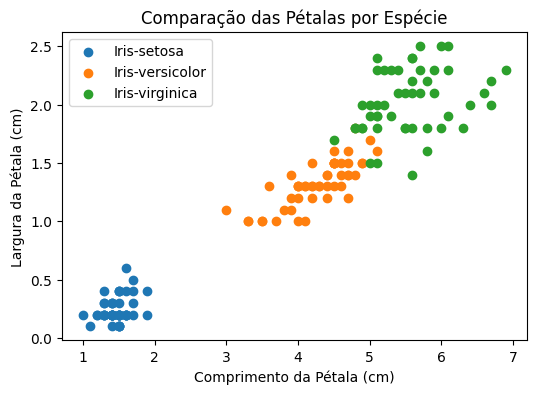

In [2]:
# Resumo geral do dataset
resumo_dataset = pd.DataFrame({
    'Quantidade de Linhas': [df.shape[0]],
    'Quantidade de Colunas': [df.shape[1]],
    'Total de Valores Nulos': [df.isnull().sum().sum()]
})

print("Resumo do Dataset:")
display(resumo_dataset)

# Informações das colunas
estrutura = pd.DataFrame({
    'Coluna': df.columns,
    'Tipo de Dado': df.dtypes.astype(str).values,
    'Valores Nulos': df.isnull().sum().values
})

print("Informações das Colunas:")
display(estrutura)

# Estatísticas descritivas
print("Estatísticas das Variáveis Numéricas:")
display(df.describe().round(2))

# Distribuição das espécies
contagem_especies = (
    df['Species']
    .value_counts()
    .rename_axis('Espécie')
    .reset_index(name='Quantidade')
)

print("Quantidade por Espécie:")
display(contagem_especies)

# Gráfico das pétalas
plt.figure()

for especie, dados_especie in df.groupby('Species'):
    plt.scatter(
        dados_especie['PetalLengthCm'],
        dados_especie['PetalWidthCm'],
        label=especie
    )

plt.xlabel('Comprimento da Pétala (cm)')
plt.ylabel('Largura da Pétala (cm)')
plt.title('Comparação das Pétalas por Espécie')
plt.legend()
plt.show()

## 3. Preparação dos Dados: Treino e Teste

Para treinar o modelo, os dados serão divididos em:

- **X:** as quatro medidas das flores;
- **y:** a espécie da flor.

Será utilizada a divisão de **80% para treino** e **20% para teste**. O parâmetro stratify=y mantém a proporção das espécies nos dois grupos.

In [3]:
# Variáveis de entrada
X = df.drop(columns=['Id', 'Species'])

# Variável que o modelo deverá prever
y = df['Species']

# Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Resultado da divisão
divisao_dados = pd.DataFrame({
    'Conjunto': ['Treino', 'Teste'],
    'Quantidade de Amostras': [
        X_train.shape[0],
        X_test.shape[0]
    ]
})

print("Divisão dos Dados:")
display(divisao_dados)

Divisão dos Dados:


,Conjunto,Quantidade de Amostras
0,Treino,120
1,Teste,30


## 4. Experimento 1: SVM Linear com Pipeline

O **Support Vector Machine (SVM)** procura uma fronteira que consiga separar as diferentes classes.

Neste primeiro experimento é utilizado o kernel **Linear**.

O Pipeline executa duas etapas:

1. StandardScaler() — coloca as medidas em uma escala semelhante;
2. SVC(kernel='linear') — treina o modelo SVM Linear.

In [4]:
pipeline_linear = Pipeline([
    ('escalonador', StandardScaler()),
    ('modelo_svm', SVC(
        kernel='linear',
        C=1.0,
        random_state=42
    ))
])

# Treinamento
pipeline_linear.fit(X_train, y_train)

# Previsões
previsoes_linear = pipeline_linear.predict(X_test)

# Acurácia
acuracia_linear = accuracy_score(
    y_test,
    previsoes_linear
)

# Resultado principal
resultado_linear = pd.DataFrame({
    'Modelo': ['SVM Linear'],
    'Acurácia': [acuracia_linear]
})

print("Resultado do SVM Linear:")
display(
    resultado_linear.style
    .format({'Acurácia': '{:.2%}'})
)

# Relatório de classificação
relatorio_linear = classification_report(
    y_test,
    previsoes_linear,
    output_dict=True
)

tabela_relatorio = (
    pd.DataFrame(relatorio_linear)
    .transpose()
)

print("Relatório de Classificação:")
display(tabela_relatorio.round(3))

Resultado do SVM Linear:


,Modelo,Acurácia
0,SVM Linear,100.00%


Relatório de Classificação:


,precision,recall,f1-score,support
Iris-setosa,1.0,1.0,1.0,10.0
Iris-versicolor,1.0,1.0,1.0,10.0
Iris-virginica,1.0,1.0,1.0,10.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,30.0
weighted avg,1.0,1.0,1.0,30.0


## 5. Experimento 2: SVM Não Linear com Kernel RBF

O kernel **RBF (Radial Basis Function)** permite que o SVM crie fronteiras de decisão não lineares.

Neste experimento será utilizado C=1.0 e gamma='scale'. Depois do treinamento, será criada uma matriz de confusão para visualizar os acertos e erros.

Acurácia do SVM RBF no teste: 96.67%


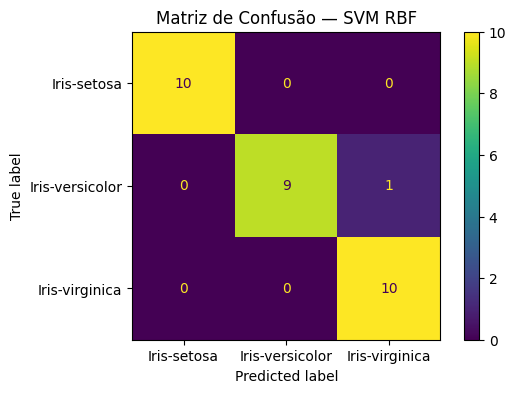

In [5]:
pipeline_rbf = Pipeline([
    ('escalonador', StandardScaler()),
    ('modelo_svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        random_state=42
    ))
])

# Treinamento e previsão
pipeline_rbf.fit(X_train, y_train)
previsoes_rbf = pipeline_rbf.predict(X_test)

# Acurácia
acuracia_rbf = accuracy_score(y_test, previsoes_rbf)

print(f"Acurácia do SVM RBF no teste: {acuracia_rbf * 100:.2f}%")

# Matriz de confusão
matriz_confusao = confusion_matrix(y_test, previsoes_rbf)

visualizacao = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao,
    display_labels=pipeline_rbf.classes_
)

visualizacao.plot()
plt.title("Matriz de Confusão — SVM RBF")
plt.show()

## 6. Validação Cruzada e Teste de Outras Configurações

Para verificar se o resultado não depende apenas de uma divisão específica entre treino e teste, será utilizada a **validação cruzada com 5 folds**.

Também serão realizados dois testes:

- kernel **Polinomial**;
- diferentes valores do parâmetro **C** no kernel RBF.

O parâmetro `C` controla o quanto o modelo penaliza erros durante o treinamento.

In [6]:
# Validação cruzada do SVM Linear e RBF
cv_linear = cross_val_score(pipeline_linear, X, y, cv=5)
cv_rbf = cross_val_score(pipeline_rbf, X, y, cv=5)

# SVM Polinomial
pipeline_poly = Pipeline([
    ('escalonador', StandardScaler()),
    ('modelo_svm', SVC(
        kernel='poly',
        degree=3,
        C=1.0,
        random_state=42
    ))
])

pipeline_poly.fit(X_train, y_train)

previsoes_poly = pipeline_poly.predict(X_test)
acuracia_poly = accuracy_score(y_test, previsoes_poly)

cv_poly = cross_val_score(pipeline_poly, X, y, cv=5)

# Tabela com os resultados de cada fold
resultados_cv = pd.DataFrame({
    'Fold': [1, 2, 3, 4, 5],
    'SVM Linear': cv_linear,
    'SVM RBF': cv_rbf,
    'SVM Polinomial': cv_poly
})

print("Resultados da Validação Cruzada:")
display(resultados_cv.round(3))

# Tabela com a média de cada modelo
medias_cv = pd.DataFrame({
    'Modelo': ['SVM Linear', 'SVM RBF', 'SVM Polinomial'],
    'Média da Validação Cruzada': [
        np.mean(cv_linear),
        np.mean(cv_rbf),
        np.mean(cv_poly)
    ]
})

print("Média dos Modelos:")
display(medias_cv.round(3))

Resultados da Validação Cruzada:


,Fold,SVM Linear,SVM RBF,SVM Polinomial
0,1,0.967,0.967,0.967
1,2,1.000,0.967,0.967
2,3,0.933,0.967,0.867
3,4,0.933,0.933,0.867
4,5,1.000,1.000,0.967


Média dos Modelos:


,Modelo,Média da Validação Cruzada
0,SVM Linear,0.967
1,SVM RBF,0.967
2,SVM Polinomial,0.927


### Testando diferentes valores de C no kernel RBF

Agora o mesmo modelo RBF será treinado com diferentes valores de `C` para observar se o desempenho muda.

In [7]:
resultados_c = []

valores_c = [0.1, 1.0, 10.0, 100.0]

for c_val in valores_c:
    modelo_c = Pipeline([
        ('escalonador', StandardScaler()),
        ('modelo_svm', SVC(
            kernel='rbf',
            C=c_val,
            gamma='scale',
            random_state=42
        ))
    ])

    modelo_c.fit(X_train, y_train)
    previsoes_c = modelo_c.predict(X_test)

    acuracia_c = accuracy_score(y_test, previsoes_c)

    resultados_c.append({
        'Valor de C': c_val,
        'Acurácia': acuracia_c
    })

# Organizando os resultados em uma tabela
tabela_c = pd.DataFrame(resultados_c)

print("Resultados dos diferentes valores de C:")
display(
    tabela_c.style
    .format({'Valor de C': '{:.1f}', 'Acurácia': '{:.2%}'})
    .highlight_max(subset=['Acurácia'])
)

Resultados dos diferentes valores de C:


,Valor de C,Acurácia
0,0.1,90.00%
1,1.0,96.67%
2,10.0,96.67%
3,100.0,96.67%


## 7. Comparação dos Modelos

A tabela abaixo compara a acurácia no conjunto de teste e a média da validação cruzada dos três modelos SVM utilizados.

In [8]:
tabela_comparacao = pd.DataFrame({
    'Modelo': [
        'SVM Linear',
        'SVM RBF',
        'SVM Polinomial'
    ],
    'Acurácia no Teste': [
        acuracia_linear,
        acuracia_rbf,
        acuracia_poly
    ],
    'Média Validação Cruzada': [
        np.mean(cv_linear),
        np.mean(cv_rbf),
        np.mean(cv_poly)
    ]
})

display(tabela_comparacao)

,Modelo,Acurácia no Teste,Média Validação Cruzada
0,SVM Linear,1.000000,0.966667
1,SVM RBF,0.966667,0.966667
2,SVM Polinomial,0.900000,0.926667
